In [2]:
# https://chatgpt.com/c/69b96d90-012c-83a4-bd0a-20a42a5cd8ff

In [3]:
import pandas as pd
import numpy as np
import torch

from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils import resample

from xgboost import XGBClassifier

from pgmpy.models import DiscreteBayesianNetwork 
from pgmpy.inference import VariableElimination

import shap
from tqdm import tqdm
import spacy    

c:\Users\Acer\miniconda3\envs\torch_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
## Sample dataset rows:

# title,news_url,source_domain,tweet_num,real
# Kandi Burruss Explodes Over Rape Accusation on 'Real Housewives of Atlanta' Reunion (Video),http://toofab.com/2017/05/08/real-housewives-atlanta-kandi-burruss-rape-phaedra-parks-porsha-williams/,toofab.com,42,1
# People's Choice Awards 2018: The best red carpet looks,https://www.today.com/style/see-people-s-choice-awards-red-carpet-looks-t141832,www.today.com,0,1


In [5]:
df = pd.read_csv("../dataset/FakeNewsNet.csv")

print(df.head())
print(df.shape)

                                               title  \
0  Kandi Burruss Explodes Over Rape Accusation on...   
1  People's Choice Awards 2018: The best red carp...   
2  Sophia Bush Sends Sweet Birthday Message to 'O...   
3  Colombian singer Maluma sparks rumours of inap...   
4  Gossip Girl 10 Years Later: How Upper East Sid...   

                                            news_url        source_domain  \
0  http://toofab.com/2017/05/08/real-housewives-a...           toofab.com   
1  https://www.today.com/style/see-people-s-choic...        www.today.com   
2  https://www.etonline.com/news/220806_sophia_bu...     www.etonline.com   
3  https://www.dailymail.co.uk/news/article-33655...  www.dailymail.co.uk   
4  https://www.zerchoo.com/entertainment/gossip-g...      www.zerchoo.com   

   tweet_num  real  
0         42     1  
1          0     1  
2         63     1  
3         20     1  
4         38     1  
(23196, 5)


In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [7]:
df = df[["title","source_domain","tweet_num","real"]]

df = df.dropna()

In [8]:
real_count = (df["real"] == 1).sum()
fake_count = (df["real"] == 0).sum()

print("Real news:", real_count)
print("Fake news:", fake_count)

Real news: 17371
Fake news: 5495


In [9]:
real = df[df["real"] == 1]
fake = df[df["real"] == 0]

# Oversample fake
fake_oversampled = resample(
    fake,
    replace=True,            # allow duplicates
    n_samples=len(real),     # match real count
    random_state=42
)

# Combine
df = pd.concat([real, fake_oversampled])

In [10]:
df = df[["title","source_domain","tweet_num","real"]]

df = df.dropna()

In [11]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["real"]
)

In [12]:
model = SentenceTransformer(
    "sentence-transformers/all-roberta-large-v1",
    device=device
)

INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: sentence-transformers/all-roberta-large-v1
INFO:httpx:HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-roberta-large-v1/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-roberta-large-v1/cf74d8acd4f198de950bf004b262e6accfed5d2c/modules.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-roberta-large-v1/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-roberta-large-v1/cf74d8acd4f198de950bf004b262e6accfed5d2c/config_sentence_transformers.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-roberta-large-v1/resolve/main/config_sentence_transfor

In [13]:
def generate_embeddings(texts):

    embeddings = model.encode(
        texts,
        batch_size=32,
        show_progress_bar=True
    )

    return np.array(embeddings)

In [14]:
X_train_embed = generate_embeddings(train_df["title"].tolist())
X_test_embed = generate_embeddings(test_df["title"].tolist())

Batches: 100%|██████████| 218/218 [00:26<00:00,  8.13it/s]


In [15]:
domain_scores = {
    "reuters.com":0.95,
    "apnews.com":0.94,
    "bbc.com":0.93,
    "thehindu.com":0.90,
    "today.com":0.88,
    "etonline.com":0.75,
    "toofab.com":0.70
}

In [16]:
def get_domain_score(domain):

    domain = domain.replace("www.","")

    return domain_scores.get(domain,0.5)

In [17]:
from transformers import pipeline

sentiment_model = pipeline(
    "sentiment-analysis",
    device=0 if device == "cuda" else -1
)

def sentiment_score(text):

    result = sentiment_model(text[:512])[0]

    if result["label"] == "POSITIVE":
        return result["score"]
    else:
        return -result["score"]

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
INFO:httpx:HTTP Request: HEAD https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english/resolve/714eb0f/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/distilbert/distilbert-base-uncased-finetuned-sst-2-english/714eb0fa89d2f80546fda750413ed43d93601a13/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english/resolve/714eb0f/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/distilbert/distilbert-base-uncased-finetuned-sst-2-english/714eb0fa89d2f80546fda750413ed43d93601a13/config.json "HTTP/1.1 200 OK"
Loading weights: 100%|█

In [18]:
clickbait_words = [
    "shocking",
    "you won't believe",
    "breaking",
    "secret",
    "exposed",
    "what happened next"
]

def clickbait_score(text):

    text = text.lower()

    score = 0

    for word in clickbait_words:
        if word in text:
            score += 1

    return score

In [19]:
trigger_words = [
    "urgent",
    "alert",
    "massive",
    "scam",
    "exclusive",
    "must see"
]

def trigger_density(text):

    words = text.lower().split()

    count = sum(word in trigger_words for word in words)

    return count / max(len(words),1)

In [20]:
def writing_style_score(text):

    length = len(text.split())

    exclam = text.count("!")

    caps = sum(1 for w in text.split() if w.isupper())

    return (exclam + caps) / max(length,1)

In [21]:
nlp = spacy.load("en_core_web_sm")

def fact_signal(text):

    doc = nlp(text)

    entities = [ent.label_ for ent in doc.ents]

    if "PERSON" in entities or "ORG" in entities or "GPE" in entities:
        return 1
    else:
        return 0

In [22]:
def build_extra_features(df):

    credibility = []
    tweets = []
    sentiment = []
    clickbait = []
    trigger = []
    writing = []
    fact = []

    for _,row in df.iterrows():

        text = row["title"]

        credibility.append(
            get_domain_score(row["source_domain"])
        )

        tweets.append(row["tweet_num"])

        sentiment.append(sentiment_score(text))

        clickbait.append(clickbait_score(text))

        trigger.append(trigger_density(text))

        writing.append(writing_style_score(text))

        fact.append(fact_signal(text))

    return np.array([
        credibility,
        tweets,
        sentiment,
        clickbait,
        trigger,
        writing,
        fact
    ]).T

In [23]:
def discretize_features(df, xgb_preds):

    credibility = []
    tweets = []
    sentiment = []
    clickbait = []
    trigger = []
    writing = []
    fact = []

    for _,row in df.iterrows():

        text = row["title"]

        cred = get_domain_score(row["source_domain"])

        credibility.append(1 if cred > 0.75 else 0)

        tweets.append(1 if row["tweet_num"] > 50 else 0)

        sentiment.append(1 if sentiment_score(text) > 0 else 0)

        clickbait.append(1 if clickbait_score(text) > 0 else 0)

        trigger.append(1 if trigger_density(text) > 0.02 else 0)

        writing.append(1 if writing_style_score(text) > 0.05 else 0)

        fact.append(int(fact_signal(text)))

    return pd.DataFrame({

        "Credibility": credibility,
        "TweetSignal": tweets,
        "Sentiment": sentiment,
        "Clickbait": clickbait,
        "TriggerWords": trigger,
        "WritingStyle": writing,
        "FactSignal": fact,
        "XGBPrediction": np.asarray(xgb_preds, dtype=int),
        "RealNews": df["real"].astype(int).values
    })

In [24]:
train_extra = build_extra_features(train_df)
test_extra = build_extra_features(test_df)

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [25]:
X_train = np.hstack([X_train_embed,train_extra])
X_test = np.hstack([X_test_embed,test_extra])

y_train = train_df["real"].values
y_test = test_df["real"].values

In [26]:
xgb_model = XGBClassifier(

    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,

    tree_method="hist",
    device="cuda",

    eval_metric="logloss"
)

In [27]:
xgb_model.fit(X_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,'cuda'
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [28]:
preds = xgb_model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,preds))

print(classification_report(y_test,preds))

c:\Users\Acer\miniconda3\envs\torch_env\lib\site-packages\xgboost\core.py:751: UserWarning: [12:44:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Accuracy: 0.9516477190962729
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      3475
           1       0.98      0.92      0.95      3474

    accuracy                           0.95      6949
   macro avg       0.95      0.95      0.95      6949
weighted avg       0.95      0.95      0.95      6949



In [44]:
bn_model = DiscreteBayesianNetwork([
    ("TriggerWords", "Clickbait"),
    ("Clickbait", "Sentiment"),
    ("WritingStyle", "Credibility"),
    ("TweetSignal", "Credibility"),
    ("FactSignal", "Credibility"),
    ("Credibility", "RealNews"),
    ("Sentiment", "RealNews"),
    ("Clickbait", "RealNews"),
    ("XGBPrediction", "RealNews")
])

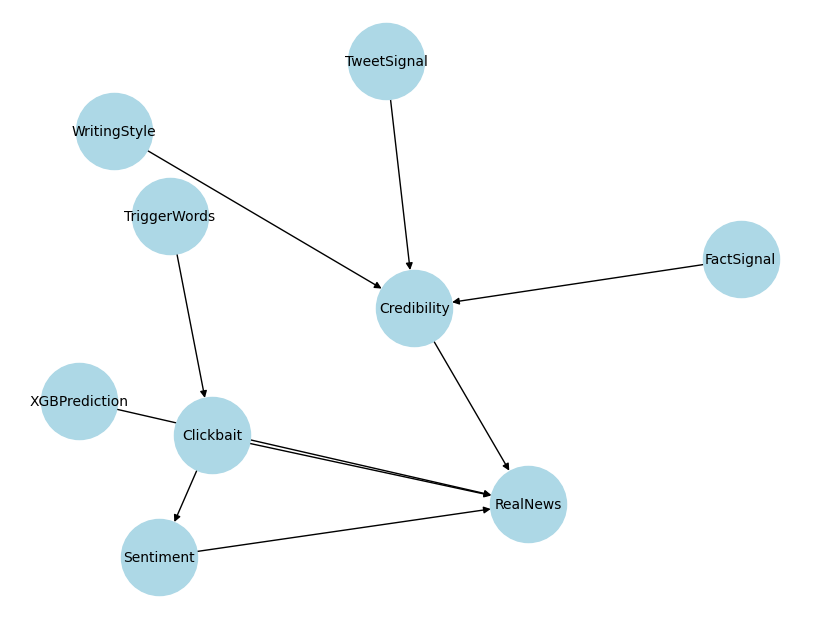

In [45]:
import networkx as nx
import matplotlib.pyplot as plt

edges = [
    ("TriggerWords", "Clickbait"),
    ("Clickbait", "Sentiment"),
    ("WritingStyle", "Credibility"),
    ("TweetSignal", "Credibility"),
    ("FactSignal", "Credibility"),
    ("Credibility", "RealNews"),
    ("Sentiment", "RealNews"),
    ("Clickbait", "RealNews"),
    ("XGBPrediction", "RealNews")
]

G = nx.DiGraph()
G.add_edges_from(edges)

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)
nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=3000,
    node_color="lightblue",
    font_size=10,
    arrows=True
)
plt.show()

In [46]:
bn_train_df, bn_calib_df = train_test_split(
    train_df,
    test_size=0.25,
    random_state=42,
    stratify=train_df["real"]
)

bn_calib_embed = generate_embeddings(bn_calib_df["title"].tolist())
bn_calib_extra = build_extra_features(bn_calib_df)
X_bn_calib = np.hstack([bn_calib_embed, bn_calib_extra])

bn_calib_preds = xgb_model.predict(X_bn_calib)
bn_train_data = discretize_features(bn_calib_df, bn_calib_preds)

Batches: 100%|██████████| 218/218 [00:25<00:00,  8.52it/s]


In [47]:
from pgmpy.estimators import MaximumLikelihoodEstimator

bn_model.fit(
    bn_train_data,
    estimator=MaximumLikelihoodEstimator
)

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Credibility': 'N', 'TweetSignal': 'N', 'Sentiment': 'N', 'Clickbait': 'N', 'TriggerWords': 'N', 'WritingStyle': 'N', 'FactSignal': 'N', 'XGBPrediction': 'N', 'RealNews': 'N'}


In [48]:
from pgmpy.inference import VariableElimination

bn_infer = VariableElimination(bn_model)

In [49]:
def predict_news(title, domain, tweet_count):

    emb = model.encode(title)

    credibility = get_domain_score(domain)
    sentiment = sentiment_score(title)
    clickbait = clickbait_score(title)
    trigger = trigger_density(title)
    writing = writing_style_score(title)
    fact = fact_signal(title)

    extra = np.array([
        credibility,
        tweet_count,
        sentiment,
        clickbait,
        trigger,
        writing,
        fact
    ])

    features = np.hstack([emb, extra]).reshape(1, -1)

    xgb_pred = int(xgb_model.predict(features)[0])

    cred_state = 1 if credibility > 0.75 else 0
    tweet_state = 1 if tweet_count > 50 else 0
    sentiment_state = 1 if sentiment > 0 else 0
    clickbait_state = 1 if clickbait > 0 else 0
    trigger_state = 1 if trigger > 0.02 else 0
    writing_state = 1 if writing > 0.05 else 0
    fact_state = int(fact)

    result = bn_infer.query(
        variables=["RealNews"],
        evidence={
            "Credibility": cred_state,
            "TweetSignal": tweet_state,
            "Sentiment": sentiment_state,
            "Clickbait": clickbait_state,
            "TriggerWords": trigger_state,
            "WritingStyle": writing_state,
            "FactSignal": fact_state,
            "XGBPrediction": xgb_pred
        }
    )

    prob_real = float(result.values[1])

    return prob_real

In [52]:
title = "USA confirms that covid was all fake and none of that ever existed."
domain = "reuters.com"
tweets = 500

r = predict_news(title, domain, tweets)
print("Probability of real news:", r)
print("Probability of fake news:", 1 - r)
print("Predicted label:", "REAL" if r >= 0.5 else "FAKE")

Batches: 100%|██████████| 1/1 [00:00<00:00,  7.75it/s]

Probability of real news: 0.0
Probability of fake news: 1.0
Predicted label: FAKE


In [51]:
sample_cases = [
    {
        "title": "Reuters reports 5000 deaths due to COVID-19 in India",
        "domain": "reuters.com",
        "tweets": 500
    },
    {
        "title": "Shocking secret cure exposed! You won't believe what happened next",
        "domain": "unknownsite-news.net",
        "tweets": 5
    }
]

for case in sample_cases:
    p_real = predict_news(case["title"], case["domain"], case["tweets"])
    p_fake = 1 - p_real
    label = "REAL" if p_real >= 0.5 else "FAKE"
    print(f"Title: {case['title']}")
    print(f"P(real)={p_real:.4f}, P(fake)={p_fake:.4f}, label={label}")
    print("-")

Batches: 100%|██████████| 1/1 [00:00<00:00, 67.05it/s]


Title: Reuters reports 5000 deaths due to COVID-19 in India
P(real)=1.0000, P(fake)=0.0000, label=REAL
-


Batches: 100%|██████████| 1/1 [00:00<00:00, 37.04it/s]

Title: Shocking secret cure exposed! You won't believe what happened next
P(real)=0.0000, P(fake)=1.0000, label=FAKE
-


In [36]:
print(np.unique(preds, return_counts=True))

(array([0, 1]), array([3663, 3286]))


In [56]:
import os
import joblib

SAVE_DIR = "saved_models"
os.makedirs(SAVE_DIR, exist_ok=True)

# 1. Sentence Transformer
model.save(os.path.join(SAVE_DIR, "sentence_transformer"))

# 2. XGBoost model
xgb_model.save_model(os.path.join(SAVE_DIR, "xgb_model.json"))

# 3. Bayesian Network (structure only)
joblib.dump(bn_model, os.path.join(SAVE_DIR, "bn_model.pkl"))

# 4. Bayesian Inference (RECREATE later, don't save)
# ❌ Don't dump bn_infer

# 5. Sentiment model (if it's sklearn or similar)
joblib.dump(sentiment_model, os.path.join(SAVE_DIR, "sentiment_model.pkl"))

# 6. spaCy model
nlp.to_disk(os.path.join(SAVE_DIR, "spacy_model"))

# 7. Other metadata
joblib.dump(
    {
        "domain_scores": domain_scores,
        "clickbait_words": clickbait_words,
        "trigger_words": trigger_words,
    },
    os.path.join(SAVE_DIR, "metadata.pkl")
)

print("✅ All models saved successfully!")

INFO:sentence_transformers.SentenceTransformer:Save model to saved_models\sentence_transformer
Writing model shards: 100%|██████████| 1/1 [00:05<00:00,  5.83s/it]


✅ All models saved successfully!
